In [1]:
import os
import torch
import numpy as np

# Global variable to track communication cost in bytes
communication_log = []

def compute_communication_cost(tensor, data_type_size=4):
    # data_type_size=4 for float32
    if isinstance(tensor, dict):
        size = sum(param.numel() for param in tensor.values())
    else:
        size = tensor.numel()
    return size * data_type_size


In [2]:

def top_k_sparsify(tensor, k=1000):
    flat = tensor.flatten()
    if flat.numel() <= k:
        return tensor
    values, indices = torch.topk(flat.abs(), k)
    mask = torch.zeros_like(flat)
    mask[indices] = 1
    sparse_tensor = (flat * mask).reshape(tensor.shape)
    return sparse_tensor

def quantize_tensor(tensor, num_bits=8):
    qmin = 0.
    qmax = 2.**num_bits - 1.
    min_val, max_val = tensor.min(), tensor.max()
    scale = (max_val - min_val) / (qmax - qmin)
    quantized = ((tensor - min_val) / scale).round().clamp(qmin, qmax)
    return quantized


In [3]:

def log_and_update(user_model, neighbor_models, k=1000, quantize=False):
    global communication_log
    # Peer-to-peer model averaging (e.g., gossip-style)
    neighbor_avg = sum(neighbor_models) / len(neighbor_models)

    # Log outgoing communication
    for neighbor_model in neighbor_models:
        delta = user_model - neighbor_model
        sparse_delta = top_k_sparsify(delta, k)
        if quantize:
            sparse_delta = quantize_tensor(sparse_delta)
        cost = compute_communication_cost(sparse_delta)
        communication_log.append(cost)
    
    # Update user model
    user_model = 0.5 * user_model + 0.5 * neighbor_avg
    return user_model


In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import gc
from itertools import product


In [5]:
from os import chdir
from pathlib import Path

new_path = Path("/Users/haowen/Documents/Decentral RS/fed-learning-main")

if new_path.exists():
    os.chdir(new_path)
    print(f"Working directory changed to: {Path.cwd()}")
else:
    print("Path does not exist.")


Working directory changed to: /Users/haowen/Documents/Decentral RS/fed-learning-main


In [6]:
# ── Cache parameters — must match hm_foaf_experiment_sampled.ipynb ───────────
TARGET_USERS           = 1000
MIN_INTERACTIONS = 20
SEED                   = 42
SAMPLED_DATA_DIR       = r"/Users/haowen/Documents/Decentral RS/rebuttal/code/7/hm_sampled"

cache_tag  = f"u{TARGET_USERS}_m{MIN_INTERACTIONS}_t25_v20_s42"
train_path = os.path.join(SAMPLED_DATA_DIR, f"train_{cache_tag}.csv")
val_path   = os.path.join(SAMPLED_DATA_DIR, f"val_{cache_tag}.csv")
test_path  = os.path.join(SAMPLED_DATA_DIR, f"test_{cache_tag}.csv")
meta_path  = os.path.join(SAMPLED_DATA_DIR, f"meta_{cache_tag}.csv")

assert all(os.path.exists(p) for p in [train_path, val_path, test_path, meta_path]), (
    f"Cached files not found in '{SAMPLED_DATA_DIR}/'.\n"
    "Run the hm_foaf_experiment_sampled.ipynb preprocessing section first "
    "to generate the cache."
)
print(f"Cache tag: {cache_tag}")


Cache tag: u1000_m20_t25_v20_s42


In [7]:
# ── Load sampled H&M dataset from cache ──────────────────────────────────────
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)
meta_df  = pd.read_csv(meta_path)

n_users = int(meta_df.loc[meta_df["key"] == "n_users", "value"].iloc[0])
n_items = int(meta_df.loc[meta_df["key"] == "n_items", "value"].iloc[0])

print(f"Loaded from cache: {cache_tag}")
print(f"Total Users: {n_users}")
print(f"Total Items: {n_items}")
train_df.head()


Loaded from cache: u1000_m20_t25_v20_s42
Total Users: 1000
Total Items: 10354


,customer_id,product_code,bought
0,837,3526,1
1,837,4408,1
2,837,2546,1
3,837,4908,1
4,837,555,1


In [8]:
class SparseFastNeighborDMF_NX:
    def __init__(self, num_users, num_items, latent_dim=10, lr=0.01,
                 alpha=0.01, beta=0.01, gamma=0.01, top_k=10):
        self.num_users = num_users
        self.num_items = num_items
        self.latent_dim = latent_dim
        self.lr = lr
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.top_k = top_k
        self.comm_cost = {u: {'sent': 0, 'recv': 0} for u in range(self.num_users)}

        self.user_factors = np.random.normal(scale=0.1, size=(num_users, latent_dim))
        self.common_item_factors = np.random.normal(scale=0.1, size=(num_items, latent_dim))
        self.personal_item_factors = {}  # (user_id, item_id) -> latent vector
        self.neighbors = {}

        # Logs
        self.epoch_times = []
        self.gradient_sharing_counts = []

    def build_neighbors_networkx(self, graph):
        """Build neighbor lists from a pre-constructed networkx graph.
        Pass graph=None for no peer sharing."""
        # FIX: use None sentinel instead of broken np.isnan check on a graph object
        G = graph if graph is not None else nx.Graph()

        for user_id in range(self.num_users):
            neighbors = list(G.neighbors(user_id)) if user_id in G else []
            if len(neighbors) > self.top_k:
                neighbors = list(np.random.choice(neighbors, size=self.top_k, replace=False))
            self.neighbors[user_id] = neighbors

    def train(self, data, val_data=None, epochs=100, patience=5, time_threshold=60):
        import time

        self.epoch_times = []
        self.gradient_sharing_counts = []
        self.train_losses = []
        self.val_losses = []
        epoch_summary = {}

        best_val_loss = float('inf')
        no_improve_count = 0

        for epoch in range(epochs):
            start_time = time.time()
            gradient_sharing_count = 0
            mse_train = 0.0

            np.random.shuffle(data)
            for user_id, item_id, rating in data:
                u = self.user_factors[user_id]
                p = self.common_item_factors[item_id]
                q_key = (user_id, item_id)
                if q_key not in self.personal_item_factors:
                    self.personal_item_factors[q_key] = np.random.normal(
                        scale=0.1, size=self.latent_dim)
                q = self.personal_item_factors[q_key]

                pred = np.dot(u, p + q)
                error = rating - pred
                mse_train += error ** 2

                grad_u = -error * (p + q) + self.alpha * u
                grad_p = -error * u + self.beta * p
                grad_q = -error * u + self.gamma * q

                self.user_factors[user_id] -= self.lr * grad_u
                self.personal_item_factors[q_key] -= self.lr * grad_q

                # FIX: user updates their own item factor unconditionally
                self.common_item_factors[item_id] -= self.lr * grad_p

                # FIX: then sends grad_p to each neighbor so they also apply it
                for neighbor_id in self.neighbors.get(user_id, []):
                    self.common_item_factors[item_id] -= self.lr * grad_p
                    gradient_sharing_count += 1

            epoch_time = time.time() - start_time
            rmse_train = np.sqrt(mse_train / len(data))

            # Validation loss
            if val_data is not None:
                mse_val = 0.0
                for user_id, item_id, rating in val_data:
                    pred = self.predict(user_id, item_id)
                    mse_val += (rating - pred) ** 2
                rmse_val = np.sqrt(mse_val / len(val_data))
            else:
                rmse_val = None

            # Store logs
            self.epoch_times.append(epoch_time)
            self.gradient_sharing_counts.append(gradient_sharing_count)
            self.train_losses.append(rmse_train)
            self.val_losses.append(rmse_val)
            epoch_summary[epoch] = {
                'time': epoch_time,
                'gradient_sharing': gradient_sharing_count,
                'train_rmse': rmse_train,
                'val_rmse': rmse_val
            }

            # Early stopping
            if rmse_val is not None:
                if rmse_val < best_val_loss:
                    best_val_loss = rmse_val
                    no_improve_count = 0
                else:
                    no_improve_count += 1

                if no_improve_count >= patience:
                    print(f"Early stopping: No improvement in validation loss for {patience} epochs.")
                    break

            if epoch_time > time_threshold:
                print(f"Early stopping: Epoch time exceeded {time_threshold} seconds.")
                break

        return epoch_summary

    def predict(self, user_id, item_id):
        u = self.user_factors[user_id]
        p = self.common_item_factors[item_id]
        q_key = (user_id, item_id)
        q = self.personal_item_factors.get(q_key, np.zeros(self.latent_dim))
        return np.dot(u, p + q)

    def compute_rmse(self, data):
        mse = 0.0
        for user_id, item_id, rating in data:
            pred = self.predict(user_id, item_id)
            mse += (rating - pred) ** 2
        return np.sqrt(mse / len(data))


In [9]:
# ── Build tuples from cached splits ──────────────────────────────────────────
# Treat first three columns as (user_id, item_id, rating) regardless of names.
def to_tuples(df):
    return list(df.iloc[:, :3].itertuples(index=False, name=None))

train_tuples = to_tuples(train_df)
val_tuples   = to_tuples(val_df)
test_tuples  = to_tuples(test_df)

print(f"Train: {len(train_tuples)} interactions")
print(f"Val  : {len(val_tuples)} interactions")
print(f"Test : {len(test_tuples)} interactions")

# ── Communication graph ───────────────────────────────────────────────────────
from src.graphs import create_graph
graph = create_graph("random_2_out", n_users=n_users, seed=SEED)
print(f"Graph built: random_2_out, {n_users} nodes")


Train: 63081 interactions
Val  : 15010 interactions
Test : 25055 interactions
Graph built: random_2_out, 1000 nodes


In [10]:
# ── Grid search ───────────────────────────────────────────────────────────────
latent_dims = [8, 10, 16]
lrs         = [0.001, 0.005, 0.01]
top_ks      = [5, 10, 15]
epochs      = 50

best_rmse   = float("inf")
best_config = None
results     = []

for dim, lr, k in product(latent_dims, lrs, top_ks):
    print(f"\nTraining config: latent_dim={dim}, lr={lr}, top_k={k}")

    model = SparseFastNeighborDMF_NX(
        num_users=n_users,
        num_items=n_items,
        latent_dim=dim,
        lr=lr,
        top_k=k
    )
    model.build_neighbors_networkx(graph)
    model.train(train_tuples, val_data=val_tuples, epochs=epochs, patience=5, time_threshold=30)

    val_rmse = model.compute_rmse(val_tuples)
    results.append((dim, lr, k, val_rmse))

    print(f"Validation RMSE: {val_rmse:.4f}")
    if val_rmse < best_rmse:
        best_rmse   = val_rmse
        best_config = (dim, lr, k)

    del model
    gc.collect()

print("\nBest configuration:")
print(f"latent_dim={best_config[0]}, lr={best_config[1]}, top_k={best_config[2]}, RMSE={best_rmse:.4f}")



Training config: latent_dim=8, lr=0.001, top_k=5
Validation RMSE: 1.3808

Training config: latent_dim=8, lr=0.001, top_k=10
Validation RMSE: 1.3103

Training config: latent_dim=8, lr=0.001, top_k=15
Validation RMSE: 1.2997

Training config: latent_dim=8, lr=0.005, top_k=5
Early stopping: No improvement in validation loss for 5 epochs.
Validation RMSE: 1.1126

Training config: latent_dim=8, lr=0.005, top_k=10
Early stopping: No improvement in validation loss for 5 epochs.
Validation RMSE: 1.1109

Training config: latent_dim=8, lr=0.005, top_k=15
Early stopping: No improvement in validation loss for 5 epochs.
Validation RMSE: 1.0946

Training config: latent_dim=8, lr=0.01, top_k=5
Early stopping: No improvement in validation loss for 5 epochs.
Validation RMSE: 1.1127

Training config: latent_dim=8, lr=0.01, top_k=10
Early stopping: No improvement in validation loss for 5 epochs.
Validation RMSE: 1.1243

Training config: latent_dim=8, lr=0.01, top_k=15
Early stopping: No improvement in v

In [11]:
# ── Retrain best config on full train set, evaluate on test ──────────────────
full_train_tuples = to_tuples(train_df)

best_model = SparseFastNeighborDMF_NX(
    num_users=n_users,
    num_items=n_items,
    latent_dim=best_config[0],
    lr=best_config[1],
    top_k=best_config[2]
)
best_model.build_neighbors_networkx(graph)
# FIX: val_data=None — do NOT pass test_tuples here (data leakage into early stopping)
best_model.train(full_train_tuples, val_data=None, epochs=50)

test_rmse = best_model.compute_rmse(test_tuples)
print(f"Test RMSE (best model): {test_rmse:.4f}")


Test RMSE (best model): 1.1531


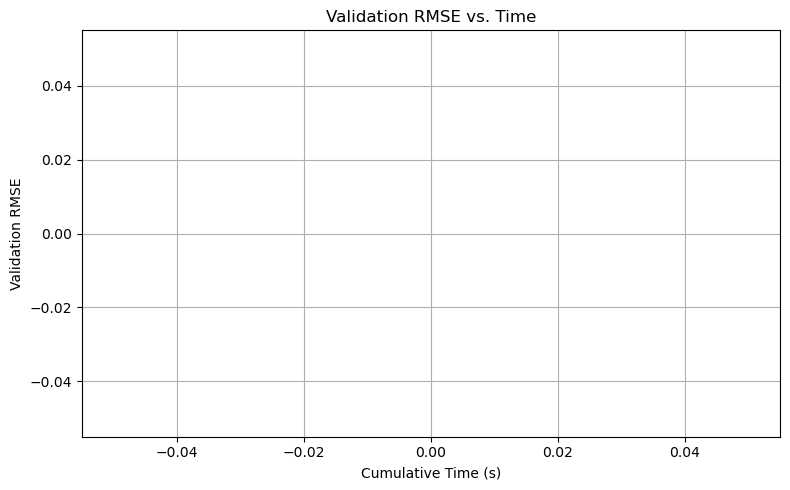

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Compute cumulative time
cumulative_time = np.cumsum(best_model.epoch_times)

# Plot validation RMSE vs. cumulative training time
plt.figure(figsize=(8, 5))
plt.plot(cumulative_time, best_model.val_losses, marker='o')
plt.xlabel("Cumulative Time (s)")
plt.ylabel("Validation RMSE")
plt.title("Validation RMSE vs. Time")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
best_model.epoch_times

[0.7123441696166992,
 0.7001330852508545,
 0.6820809841156006,
 0.7103590965270996,
 0.7043299674987793,
 0.7222869396209717,
 0.6563410758972168,
 0.6968412399291992,
 0.6703619956970215,
 0.6920130252838135,
 0.6831896305084229,
 0.6601300239562988,
 0.6769840717315674,
 0.6899547576904297,
 0.6660490036010742,
 0.672788143157959,
 0.6950819492340088,
 0.674144983291626,
 0.7188348770141602,
 0.7253098487854004,
 0.662330150604248,
 0.6712801456451416,
 0.7062721252441406,
 0.6847727298736572,
 0.6596872806549072,
 0.6776120662689209,
 0.6792619228363037,
 0.6833460330963135,
 0.6952431201934814,
 0.6957950592041016,
 0.6987221240997314,
 0.699822187423706,
 0.6958928108215332,
 0.6562981605529785,
 0.680150032043457,
 0.708885908126831,
 0.6799707412719727,
 0.659757137298584,
 0.6949357986450195,
 0.7069540023803711,
 0.6819109916687012,
 0.6983098983764648,
 0.6831347942352295,
 0.6607961654663086,
 0.723132848739624,
 0.6812539100646973,
 0.7386410236358643,
 0.7026731967926025,


In [14]:
best_model.gradient_sharing_counts 

[126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084,
 126084]

In [15]:
best_model.val_losses

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [16]:
log ={}
log["rmse"] = best_model.val_losses
log["cost"] = best_model.gradient_sharing_counts 
log["time"] = best_model.epoch_times

In [17]:
# FIX: pd.DataFrame(log) produces 50-row x 3-col table
# (from_dict orient='index' produced an inverted 3-row x 50-col table)
df = pd.DataFrame(log)          # columns: rmse, cost, time; one row per epoch
df.index.name = "epoch"
df.reset_index(inplace=True)
df.to_csv("dmf_hm.csv", index=False)
df.head()


,epoch,rmse,cost,time
0,0,None,126084,0.712344
1,1,None,126084,0.700133
2,2,None,126084,0.682081
3,3,None,126084,0.710359
4,4,None,126084,0.704330
